In [1]:
using CondaPkg
CondaPkg.add_pip("ggblab", version="@ file:///Users/manabu/work/ggblab/dist/ggblab-1.7.1-py3-none-any.whl")

    CondaPkg Found dev dependencies: /Users/manabu/work/ggblab/julia/GeoGebra.jl/CondaPkg.toml
    CondaPkg Found dependencies: /Users/manabu/.julia/packages/PythonCall/83z4q/CondaPkg.toml
    CondaPkg Found dependencies: /Users/manabu/.julia/packages/CondaPkg/8GjrP/CondaPkg.toml
    CondaPkg Found dependencies: /Users/manabu/.julia/environments/v1.12/CondaPkg.toml
    CondaPkg Found dependencies: /Users/manabu/.julia/packages/CondaPkg/HctRf/CondaPkg.toml
    CondaPkg Initialising pixi
             │ /Users/manabu/.julia/artifacts/d2fecc2a9fa3eac2108d3e4d9d155e6ff5dfd0b2/bin/pixi
             │ init
             │ --format pixi
             └ /Users/manabu/work/ggblab/julia/GeoGebra.jl/.CondaPkg
✔ Created /Users/manabu/work/ggblab/julia/GeoGebra.jl/.CondaPkg/pixi.toml
    CondaPkg Wrote /Users/manabu/work/ggblab/julia/GeoGebra.jl/.CondaPkg/pixi.toml
             │ [dependencies]
             │ openssl = ">=3, <3.6"
             │ uv = ">=0.4"
             │ 
             │     [depende

In [2]:
# using Revise
# using Pkg
# Pkg.instantiate()
# Pkg.status()
# Pkg.resolve()

In [3]:
ENV["GGBLAB_DISABLE_PERSISTENT_COUNTER"] = "1"

"1"

In [4]:
using Pkg
Pkg.activate("/Users/manabu/work/ggblab/julia/GeoGebra.jl")  # または Pkg.activate(pwd())
Pkg.instantiate()
using GeoGebra

  Activating project at `~/work/ggblab/julia/GeoGebra.jl`


In [5]:
# Pkg.add("GeoGebra")
# Pkg.rm("GeoGebra")

In [6]:
# Pkg.free("GeoGebra")
# Pkg.develop(url="..")

In [7]:
# Pkg.add(url="https://github.com/moyhig-ecs/GeoGebra.jl.git")
# Pkg.develop(url="..")
# Pkg.instantiate()
# Pkg.precompile()
using GeoGebra

In [8]:
# GeoGebra.set_default_port(8765)

In [9]:
using PythonCall

In [10]:
using GeoGebra
@ggb api getVersion()

"5.4.916.2"

In [11]:
p1 = @ggb :O = (0,0)

O

Info: PersistentCounter disabled via GGBLAB_DISABLE_PERSISTENT_COUNTER env
Info: PersistentCounter disabled via GGBLAB_DISABLE_PERSISTENT_COUNTER env


In [12]:
# stores reply in x (unwrapped)
p1 = @ggb :O = (0,0)

O

In [13]:
@ggb api setCoords(:O, 3, 4)

In [14]:
refresh!(p1)

O

In [15]:
PyDict(p1.data["element"][0])

PyDict{Py, Py} with 10 entries:
  '@type'      => 'point'
  '@label'     => 'O'
  'show'       => [{'@object': True, '@label': False}]
  'objColor'   => [{'@r': 21, '@g': 101, '@b': 192, '@alpha': 0.0}]
  'layer'      => [{'@val': 0}]
  'labelMode'  => [{'@val': 0}]
  'animation'  => [{'@step': '0.1', '@type': 1, '@playing': False}]
  'pointSize'  => [{'@val': 5.0}]
  'pointStyle' => [{'@val': 0}]
  'coords'     => [{'@x': '3', '@y': '4', '@z': '1'}]

In [16]:
p1.data["element"][0]["show"][0]["@label"] = false

false

In [17]:
set!(p1)

In [18]:
p1.data["element"]

Python: [{'@type': 'point', '@label': 'O', 'show': [{'@object': True, '@label': False}], 'objColor': [{'@r': 21, '@g': 101, '@b': 192, '@alpha': 0.0}], 'layer': [{'@val': 0}], 'labelMode': [{'@val': 0}], 'animation': [{'@step': '0.1', '@type': 1, '@playing': False}], 'pointSize': [{'@val': 5.0}], 'pointStyle': [{'@val': 0}], 'coords': [{'@x': '3', '@y': '4', '@z': '1'}]}]

In [19]:
using PythonCall

In [24]:
using PythonCall
ggb = pyimport("ggblab")
ggb.connect_to_bridge()

Python: True

In [25]:
p1 = @ggb :O = (0,0)
p1.data["element"][0]["show"][0]["@label"] = false

false

In [26]:
xmlschema = pyimport("xmlschema")
xml_str = xmlschema.etree_tostring(ggb.schema.encode(p1.data["element"][0], "element"))
@ggb api evalXML(xml_str)

In [27]:
c1 = @ggb :c = Circle(p1, 1)

c

In [14]:
l1 = @ggb :l1 = {Intersect(c, f)}
@ggb :l1(1)
@ggb :l1(2)

F

In [13]:
using PythonCall
ggb = pyimport("ggblab")
ggb.connect_to_bridge()

Python: True

In [28]:
@await ggb.function("getVersion")

Python: '5.4.916.2'

In [11]:
ggbex = pyimport("ggblab_extra")
ConstructionIO = ggbex.ConstructionIO
df = @await ConstructionIO.initialize_dataframe(ggb, use_applet=true)

Sequence,Name,Type,Command,Value,Caption,Layer,ShowObject,ShowLabel,Auxiliary
u32,str,str,str,str,str,u32,bool,bool,bool
1,"""O""","""point""","""(0, 0)""","""O = (0, 0)""",null,0,false,false,false


In [23]:
using Base.Checked

In [25]:
try
    checked_pow(2, 64)
catch e
    println(e)
end

OverflowError("4294967296 * 4294967296 overflowed for type Int64")


In [15]:
big(2)^64

18446744073709551616

In [16]:
pyint(big(2)^64)

Python: 18446744073709551616

In [30]:
pl = pyimport("polars")

Python: <module 'polars' from '/Users/manabu/.julia/environments/v1.12/.CondaPkg/.pixi/envs/default/lib/python3.14/site-packages/polars/__init__.py'>

In [32]:
df2.filter(~pl.col("Name").is_in(["A"]))

Sequence,Name,Type,Command,Value,Caption,Layer,ShowObject,ShowLabel,Auxiliary
u32,str,str,str,str,str,u32,bool,bool,bool
1,"""O""","""point""","""(0, 0)""","""O = (0, 0)""",null,0,false,false,false
2,"""c""","""circle""","""Circle(O, 1)""","""c: x² + y² = 1""",null,0,true,true,false
4,"""B""","""point""",null,"""B = (0.6312356876012, 0.346998…",null,0,true,true,false
5,"""f""","""line""","""Line(A, B)""","""f: -1.0836742499787x + 0.40823…",null,0,true,true,false
6,"""l1""","""list""","""{Intersect(c, f)}""","""l1 = {(0.1268477799127, -0.991…",null,0,true,true,false


In [33]:
ggbex_sympy = pyimport("ggblab_extra.sympy")

Python: <module 'ggblab_extra.sympy' from '/Users/manabu/.julia/environments/v1.12/.CondaPkg/.pixi/envs/default/lib/python3.14/site-packages/ggblab_extra/sympy/__init__.py'>

In [34]:
df3 = ggbex_sympy.attach_object2d(df2)["Name", "Type", "object2d"]

Name,Type,object2d
str,str,object
"""O""","""point""","Object2D(kind='point', obj=Point2D(0, 0), value='O = (0, 0)', command='(0, 0)')"
"""c""","""circle""","Object2D(kind='circle', obj=Circle(Point2D(0, 0), 1), value='c: x² + y² = 1', command='Circle(O, 1)')"
"""A""","""point""","Object2D(kind='point', obj=Point2D(557505593167/2500000000000, -920844771493/1250000000000), value='A = (0.2230022372668, -0.7366758171944)', command=None)"
"""B""","""point""","Object2D(kind='point', obj=Point2D(1578089219003/2500000000000, 3469984327843/10000000000000), value='B = (0.6312356876012, 0.3469984327843)', command=None)"
"""f""","""line""","Object2D(kind='line', obj=Line2D(Point2D(0, -66432269624231/50000000000000), Point2D(-255145906459/625000000000, -60307991061583/25000000000000)), value='f: -1.0836742499787x + 0.4082334503344y = -0.5423974928449', command='Line(A, B)')"
"""l1""","""list""",null


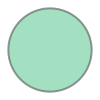

In [35]:
c = df3.filter(pl.col("Name").is_in(["c"]))["object2d"].item().obj

In [36]:
c.center

Python: Point2D(0, 0)

In [37]:
nx = pyimport("networkx")

Python: <module 'networkx' from '/Users/manabu/.julia/environments/v1.12/.CondaPkg/.pixi/envs/default/lib/python3.14/site-packages/networkx/__init__.py'>

In [38]:
p = ggbex.ConstructionTreeParser(df2)

Python: <ggblab_extra.construction_parser.ConstructionTreeParser object at 0x154d38590>

In [39]:
g1 = p.parse()

Python: <networkx.classes.digraph.DiGraph object at 0x1535aa490>

In [40]:
nx.write_network_text(g1)

Python: None

╟── O
╎   └─╼ c
╎       └─╼ l1 ╾ f
╟── A
╎   └─╼ f ╾ B
╎       └─╼  ...
╟── B
╎   └─╼  ...
╙── l1
